# Rank-abundance threshold robustness

This notebook asks whether the lifestyle results change when the microbial-background multiplier is varied.

It uses the 36 samples and the numeric multiplier series from 11: 1.0x, 1.25x, 1.5x, 2.0x, 3.0x, and 5.0x. Run 11 first because its explicit threshold-membership table is the input here.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, wilcoxon
from IPython.display import SVG, display

VIRAL_FRACTION_DIR = Path("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION")
FIGURES_TABLES_DIR = VIRAL_FRACTION_DIR / "FIGURES_AND_TABLES"
VIRAL_MAPPING_DIR = VIRAL_FRACTION_DIR / "06_MAPPING"
RPKM_THRESHOLD_DIR = VIRAL_MAPPING_DIR / "REFERENCES"
VOTU_METADATA_PATH = VIRAL_FRACTION_DIR / "vOTU_metadata.csv"

THRESHOLD_SELECTION_OUTPUT_DIR = (
    FIGURES_TABLES_DIR
    / "SUPPLEMENTARY"
    / "11_rank_abundance_threshold_selection"
)
FULL_THRESHOLD_MEMBERSHIP_PATH = (
    THRESHOLD_SELECTION_OUTPUT_DIR / "11_full_phyllosphere_threshold_membership.csv"
)

OUTPUT_DIR = (
    FIGURES_TABLES_DIR
    / "SUPPLEMENTARY"
    / "14_rank_abundance_threshold_robustness"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLES_36 = [
    "vFL", "vOL", "vF23",
    "vN1", "vN2", "vN3",
    "vZ1", "vZ2", "vZ3",
    "vF1A", "vF2A", "vF3A",
    "vF1B", "vF2B", "vF3B",
    "vF1C", "vF2C", "vF3C",
    "vO1A", "vO2A", "vO3A",
    "vO1B", "vO2B", "vO3B",
    "vO1C", "vO2C", "vO3C",
    "vS1B", "vS2B", "vS3B",
    "vS1C", "vS2C", "vS3C",
    "vNWd", "vSWd", "vSEd",
]

THRESHOLD_KEYS = ["1.0", "1.25", "1.5", "2.0", "3.0", "5.0"]
DEFAULT_THRESHOLD_KEY = "1.5"
LIFESTYLE_ORDER = ["Temperate", "Virulent"]
LIFESTYLE_PALETTE = ["#3399CC", "#FF9966"]

if not FULL_THRESHOLD_MEMBERSHIP_PATH.exists():
    raise FileNotFoundError(
        "Run 11 first. Missing threshold membership table: "
        f"{FULL_THRESHOLD_MEMBERSHIP_PATH}"
    )

threshold_membership = pd.read_csv(
    FULL_THRESHOLD_MEMBERSHIP_PATH,
    dtype={"threshold_multiplier": str, "vOTU": str},
)
required_membership_columns = {
    "threshold_multiplier",
    "vOTU",
    "rank_abundance_call",
}
missing_membership_columns = sorted(
    required_membership_columns.difference(threshold_membership.columns)
)
if missing_membership_columns:
    raise ValueError(
        "11 membership table is missing columns: "
        f"{missing_membership_columns}"
    )

available_thresholds = set(threshold_membership["threshold_multiplier"])
missing_thresholds = [
    threshold
    for threshold in THRESHOLD_KEYS
    if threshold not in available_thresholds
]
if missing_thresholds:
    raise ValueError(
        "11 membership table is missing tested multipliers: "
        f"{missing_thresholds}"
    )

votu_metadata = pd.read_csv(VOTU_METADATA_PATH, low_memory=False)
votu_metadata["vOTU"] = votu_metadata["vOTU"].astype(str)

def rpkm_path(threshold):
    return (
        RPKM_THRESHOLD_DIR
        / f"filtered_active_vOTUs_threshold_{threshold.replace('.', 'p')}_RPKM_normalised_tot.txt"
    )


## Candidate-set stability

This table compares each selected set with the primary 1.5x set. It reports the number of retained vOTUs and the Jaccard overlap, without treating another activity method as ground truth.

In [2]:
default_votu_ids = set(
    threshold_membership.loc[
        threshold_membership["threshold_multiplier"].eq(DEFAULT_THRESHOLD_KEY)
        & threshold_membership["rank_abundance_call"].eq("retained"),
        "vOTU",
    ]
)

stability_rows = []
for threshold in THRESHOLD_KEYS:
    retained_votu_ids = set(
        threshold_membership.loc[
            threshold_membership["threshold_multiplier"].eq(threshold)
            & threshold_membership["rank_abundance_call"].eq("retained"),
            "vOTU",
        ]
    )
    shared_votu_ids = retained_votu_ids.intersection(default_votu_ids)
    union_votu_ids = retained_votu_ids.union(default_votu_ids)
    stability_rows.append(
        {
            "threshold_multiplier": threshold,
            "n_retained_vOTUs": len(retained_votu_ids),
            "shared_with_1.5x": len(shared_votu_ids),
            "jaccard_with_1.5x": (
                len(shared_votu_ids) / len(union_votu_ids)
                if union_votu_ids
                else np.nan
            ),
            "additional_relative_to_1.5x": len(
                retained_votu_ids.difference(default_votu_ids)
            ),
            "not_retained_relative_to_1.5x": len(
                default_votu_ids.difference(retained_votu_ids)
            ),
            "is_primary_threshold": threshold == DEFAULT_THRESHOLD_KEY,
        }
    )

threshold_stability = pd.DataFrame(stability_rows)
threshold_stability.to_csv(
    OUTPUT_DIR / "14_threshold_set_stability.csv",
    index=False,
)

threshold_stability_display = threshold_stability.copy()
threshold_stability_display["jaccard_with_1.5x"] = (
    threshold_stability_display["jaccard_with_1.5x"].round(3)
)
display(threshold_stability_display)


,threshold_multiplier,n_retained_vOTUs,shared_with_1.5x,jaccard_with_1.5x,additional_relative_to_1.5x,not_retained_relative_to_1.5x,is_primary_threshold
0,1.0,1045,726,0.695,319,0,False
1,1.25,861,726,0.843,135,0,False
2,1.5,726,726,1.000,0,0,True
3,2.0,559,559,0.770,0,167,False
4,3.0,397,397,0.547,0,329,False
5,5.0,254,254,0.350,0,472,False


## Lifestyle patterns across thresholds

For every threshold, the three panels below recalculate the same lifestyle summaries used in the rank-abundance analysis: relative abundance within each sample, prevalence across samples, and the proportion of detected vOTUs within each sample.

In [3]:
relative_abundance_rows = []
prevalence_frames = []
detected_votu_rows = []
threshold_votu_counts = {}

metadata_for_lifestyle = (
    votu_metadata[["vOTU", "BACPLHIP_lifestyle"]]
    .drop_duplicates("vOTU")
    .copy()
)

for threshold in THRESHOLD_KEYS:
    selected_votu_ids = set(
        threshold_membership.loc[
            threshold_membership["threshold_multiplier"].eq(threshold)
            & threshold_membership["rank_abundance_call"].eq("retained"),
            "vOTU",
        ]
    )
    threshold_votu_counts[threshold] = len(selected_votu_ids)

    current_rpkm_path = rpkm_path(threshold)
    if not current_rpkm_path.exists():
        raise FileNotFoundError(
            f"Missing RPKM table for threshold {threshold}: {current_rpkm_path}"
        )

    rpkm = pd.read_csv(current_rpkm_path, low_memory=False)
    rpkm["vOTU"] = rpkm["vOTU"].astype(str)
    missing_samples = sorted(set(SAMPLES_36).difference(rpkm.columns))
    if missing_samples:
        raise ValueError(
            f"RPKM table for {threshold} is missing sample columns: {missing_samples}"
        )

    selected = (
        metadata_for_lifestyle.loc[
            metadata_for_lifestyle["vOTU"].isin(selected_votu_ids)
        ]
        .merge(
            rpkm.loc[
                rpkm["vOTU"].isin(selected_votu_ids),
                ["vOTU"] + SAMPLES_36,
            ],
            on="vOTU",
            how="left",
        )
    )
    if len(selected) != len(selected_votu_ids):
        missing_metadata = sorted(
            selected_votu_ids.difference(set(selected["vOTU"]))
        )
        raise ValueError(
            f"Metadata are missing {len(missing_metadata)} vOTUs at {threshold}: "
            f"{missing_metadata[:5]}"
        )
    selected[SAMPLES_36] = selected[SAMPLES_36].fillna(0.0)

    for sample in SAMPLES_36:
        total_abundance = selected[sample].sum()
        detected = selected[sample].gt(0)
        total_detected = int(detected.sum())

        for lifestyle in LIFESTYLE_ORDER:
            lifestyle_mask = selected["BACPLHIP_lifestyle"].eq(lifestyle)
            relative_abundance_rows.append(
                {
                    "threshold": threshold,
                    "sample": sample,
                    "lifestyle": lifestyle,
                    "relative_abundance_percent": (
                        100 * selected.loc[lifestyle_mask, sample].sum()
                        / total_abundance
                        if total_abundance > 0
                        else np.nan
                    ),
                }
            )
            detected_votu_rows.append(
                {
                    "threshold": threshold,
                    "sample": sample,
                    "lifestyle": lifestyle,
                    "detected_votu_percent": (
                        100 * (lifestyle_mask & detected).sum() / total_detected
                        if total_detected > 0
                        else np.nan
                    ),
                }
            )

    prevalence = selected[["vOTU", "BACPLHIP_lifestyle"]].copy()
    prevalence["prevalence"] = (
        selected[SAMPLES_36].gt(0).sum(axis=1) / len(SAMPLES_36)
    )
    prevalence = prevalence.loc[
        prevalence["BACPLHIP_lifestyle"].isin(LIFESTYLE_ORDER)
    ].rename(columns={"BACPLHIP_lifestyle": "lifestyle"})
    prevalence["threshold"] = threshold
    prevalence_frames.append(prevalence)

relative_abundance = pd.DataFrame(relative_abundance_rows).dropna(
    subset=["relative_abundance_percent"]
)
prevalence_by_threshold = pd.concat(prevalence_frames, ignore_index=True)
detected_votu_proportion = pd.DataFrame(detected_votu_rows).dropna(
    subset=["detected_votu_percent"]
)

test_rows = []
for threshold in THRESHOLD_KEYS:
    for metric, frame, value_column in [
        (
            "relative_abundance",
            relative_abundance,
            "relative_abundance_percent",
        ),
        (
            "detected_votu_proportion",
            detected_votu_proportion,
            "detected_votu_percent",
        ),
    ]:
        paired = (
            frame.loc[frame["threshold"].eq(threshold)]
            .pivot(index="sample", columns="lifestyle", values=value_column)
            .dropna()
        )
        try:
            statistic, p_value = wilcoxon(
                paired["Temperate"],
                paired["Virulent"],
            )
        except ValueError:
            statistic, p_value = np.nan, np.nan

        test_rows.append(
            {
                "threshold": threshold,
                "metric": metric,
                "test": "Wilcoxon signed-rank",
                "n": len(paired),
                "statistic": statistic,
                "p_value": p_value,
            }
        )

    prevalence_current = prevalence_by_threshold.loc[
        prevalence_by_threshold["threshold"].eq(threshold)
    ]
    temperate_prevalence = prevalence_current.loc[
        prevalence_current["lifestyle"].eq("Temperate"),
        "prevalence",
    ].dropna()
    virulent_prevalence = prevalence_current.loc[
        prevalence_current["lifestyle"].eq("Virulent"),
        "prevalence",
    ].dropna()
    statistic, p_value = mannwhitneyu(
        temperate_prevalence,
        virulent_prevalence,
        alternative="two-sided",
    )
    test_rows.append(
        {
            "threshold": threshold,
            "metric": "prevalence",
            "test": "Mann-Whitney U",
            "n": len(temperate_prevalence) + len(virulent_prevalence),
            "statistic": statistic,
            "p_value": p_value,
        }
    )

lifestyle_threshold_tests = pd.DataFrame(test_rows)
lifestyle_threshold_tests.to_csv(
    OUTPUT_DIR / "14_lifestyle_threshold_sensitivity_tests.csv",
    index=False,
)

relative_means = (
    relative_abundance
    .groupby(["threshold", "lifestyle"], as_index=False)
    ["relative_abundance_percent"]
    .mean()
    .pivot(index="threshold", columns="lifestyle", values="relative_abundance_percent")
    .rename(
        columns={
            "Temperate": "mean_temperate_relative_abundance_percent",
            "Virulent": "mean_virulent_relative_abundance_percent",
        }
    )
    .reset_index()
)
test_pvalues = (
    lifestyle_threshold_tests
    .pivot(index="threshold", columns="metric", values="p_value")
    .rename(
        columns={
            "relative_abundance": "relative_abundance_p_value",
            "prevalence": "prevalence_p_value",
            "detected_votu_proportion": "detected_votu_proportion_p_value",
        }
    )
    .reset_index()
)

threshold_robustness_summary = (
    threshold_stability
    .merge(
        relative_means,
        left_on="threshold_multiplier",
        right_on="threshold",
        how="left",
    )
    .drop(columns="threshold")
    .merge(
        test_pvalues,
        left_on="threshold_multiplier",
        right_on="threshold",
        how="left",
    )
    .drop(columns="threshold")
)
threshold_robustness_summary.to_csv(
    OUTPUT_DIR / "14_lifestyle_threshold_robustness_summary.csv",
    index=False,
)

threshold_robustness_display = threshold_robustness_summary.copy()
for column in [
    "jaccard_with_1.5x",
    "mean_temperate_relative_abundance_percent",
    "mean_virulent_relative_abundance_percent",
    "relative_abundance_p_value",
    "prevalence_p_value",
    "detected_votu_proportion_p_value",
]:
    threshold_robustness_display[column] = (
        threshold_robustness_display[column].round(3)
    )
display(threshold_robustness_display)


,threshold_multiplier,n_retained_vOTUs,shared_with_1.5x,jaccard_with_1.5x,additional_relative_to_1.5x,not_retained_relative_to_1.5x,is_primary_threshold,mean_temperate_relative_abundance_percent,mean_virulent_relative_abundance_percent,detected_votu_proportion_p_value,prevalence_p_value,relative_abundance_p_value
0,1.0,1045,726,0.695,319,0,False,58.221,41.779,0.010,0.0,0.023
1,1.25,861,726,0.843,135,0,False,58.533,41.467,0.004,0.0,0.027
2,1.5,726,726,1.000,0,0,True,58.577,41.423,0.007,0.0,0.026
3,2.0,559,559,0.770,0,167,False,59.047,40.953,0.000,0.0,0.023
4,3.0,397,397,0.547,0,329,False,60.076,39.924,0.000,0.0,0.010
5,5.0,254,254,0.350,0,472,False,61.035,38.965,0.000,0.0,0.009


## Threshold-sensitivity figure

The figure shows the same three lifestyle comparisons at every multiplier. The number below each multiplier is the number of retained phyllosphere vOTUs.

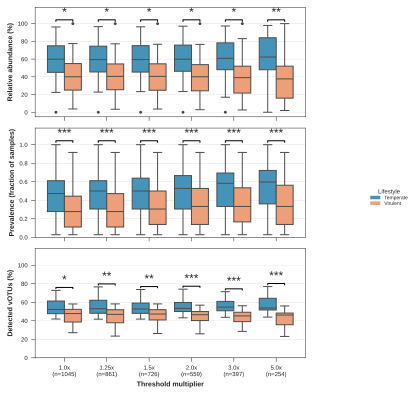

In [4]:
def significance_label(p_value):
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"

def add_lifestyle_significance_bars(axis, metric, frame, value_column):
    for position, threshold in enumerate(THRESHOLD_KEYS):
        test_row = lifestyle_threshold_tests.loc[
            lifestyle_threshold_tests["threshold"].eq(threshold)
            & lifestyle_threshold_tests["metric"].eq(metric)
        ]
        if test_row.empty or pd.isna(test_row["p_value"].iloc[0]):
            continue

        ymax = frame.loc[
            frame["threshold"].eq(threshold),
            value_column,
        ].max()
        y = ymax * 1.025 if ymax > 0 else 0.01
        height = ymax * 0.018 if ymax > 0 else 0.01
        label = significance_label(test_row["p_value"].iloc[0])
        label_fontsize = 7 if label == "ns" else 12
        label_offset = 2.5 if label == "ns" else 1.5

        axis.plot(
            [position - 0.2, position - 0.2, position + 0.2, position + 0.2],
            [y, y + height, y + height, y],
            lw=1,
            color="black",
        )
        axis.annotate(
            label,
            xy=(position, y + height),
            xytext=(0, label_offset),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=label_fontsize,
        )

threshold_labels = {
    threshold: f"{threshold}x\n(n={threshold_votu_counts[threshold]})"
    for threshold in THRESHOLD_KEYS
}
boxplot_flierprops = {
    "marker": "o",
    "markersize": 2,
    "markerfacecolor": "black",
    "markeredgecolor": "black",
    "alpha": 0.6,
}
lifestyle_figure_path = OUTPUT_DIR / "14_lifestyle_threshold_sensitivity.svg"

with sns.axes_style("ticks", {"axes.grid": True}), plt.rc_context(
    {
        "axes.linewidth": 0.5,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "grid.linewidth": 0.25,
        "patch.linewidth": 0,
        "patch.edgecolor": "none",
        "font.family": "sans-serif",
        "font.sans-serif": ["Liberation Sans"],
        "font.size": 5,
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "axes.titlepad": 7,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "axes.labelweight": "bold",
        "axes.titleweight": "bold",
        "legend.fontsize": 5,
        "legend.title_fontsize": 6,
        "legend.labelspacing": 0.2,
        "svg.fonttype": "none",
    }
):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(5, 5.5), sharex=True)
    plot_specs = [
        (
            axes[0],
            relative_abundance,
            "relative_abundance_percent",
            "Relative abundance (%)",
            "relative_abundance",
            (-5, 118),
        ),
        (
            axes[1],
            prevalence_by_threshold,
            "prevalence",
            "Prevalence (fraction of samples)",
            "prevalence",
            (0, 1.18),
        ),
        (
            axes[2],
            detected_votu_proportion,
            "detected_votu_percent",
            "Detected vOTUs (%)",
            "detected_votu_proportion",
            (0, 118),
        ),
    ]

    legend_handles = None
    legend_labels = None
    for axis, frame, value_column, ylabel, metric, ylim in plot_specs:
        sns.boxplot(
            data=frame,
            x="threshold",
            y=value_column,
            hue="lifestyle",
            order=THRESHOLD_KEYS,
            hue_order=LIFESTYLE_ORDER,
            palette=LIFESTYLE_PALETTE,
            flierprops=boxplot_flierprops,
            ax=axis,
        )
        add_lifestyle_significance_bars(axis, metric, frame, value_column)
        axis.set_ylabel(ylabel)
        axis.set_xlabel("")
        axis.set_ylim(*ylim)

        handles, labels = axis.get_legend_handles_labels()
        if legend_handles is None:
            legend_handles = handles[:2]
            legend_labels = labels[:2]
        legend = axis.get_legend()
        if legend is not None:
            legend.remove()

    axes[-1].set_xlabel("Threshold multiplier")
    axes[-1].set_xticks(
        range(len(THRESHOLD_KEYS)),
        [threshold_labels[threshold] for threshold in THRESHOLD_KEYS],
    )
    fig.legend(
        legend_handles,
        legend_labels,
        title="Lifestyle",
        frameon=False,
        bbox_to_anchor=(1.02, 0.5),
        loc="center left",
        borderaxespad=0,
    )
    fig.tight_layout(rect=[0, 0, 0.86, 1])
    fig.savefig(lifestyle_figure_path, format="svg", bbox_inches="tight")

display(SVG(filename=str(lifestyle_figure_path)))
plt.close(fig)
